# load Detection model #

In [1035]:
import torch
import glob
import os

PATH = 'detectionModel.pt'
model = torch.load(PATH)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Load test Image ##

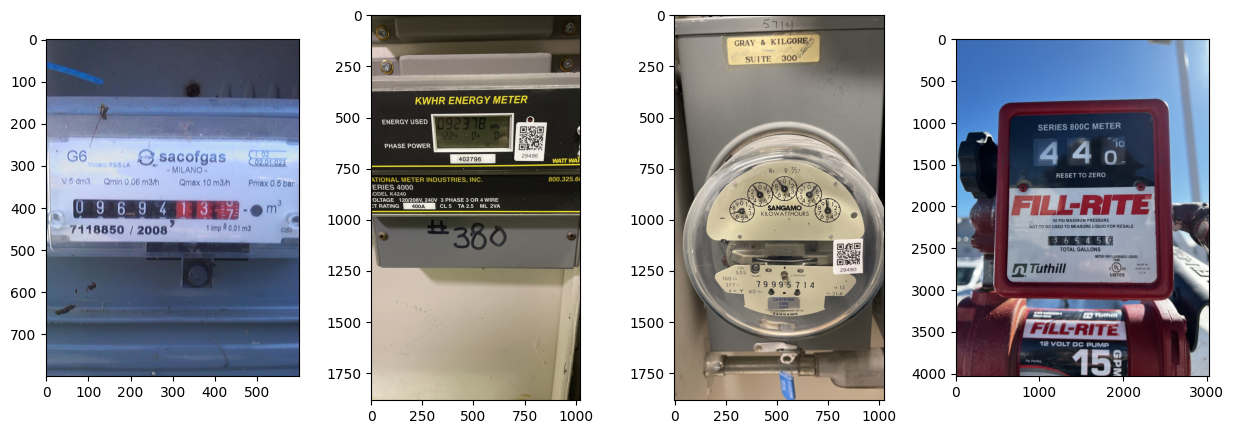

In [1036]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt

imgs = []
for i, file in enumerate(glob.glob('test/*.jpg')):
    img = Image.open(file)
    imgs.append(img)

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(imgs[0])
axarr[1].imshow(imgs[1])
axarr[2].imshow(imgs[2])
axarr[3].imshow(imgs[3])
plt.show()

## Region detection and type classification ##
model output bounding boxes and type of meters as label

In [1037]:
import torchvision.transforms as T

transform = T.ToTensor()
xywh = []
type = []
for i, img in enumerate(imgs):

    img = transform(img)
    with torch.no_grad():
        prediction = model([img])

    bboxes, labels, scores = prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']
    index = torch.argmax(scores).item()
    bbox = bboxes[index]
    x,y,w,h = bbox.detach().numpy()
    x,y,w,h = int(x), int(y), int(w), int(h)
    xywh.append([x,y,w,h])
    if(labels[index].item() == 1):
        type.append('anolog')
    elif(labels[index].item() == 2):
        type.append('digital')
    elif(labels[index].item() == 3):
        type.append('dial')
xywh,type

([[62, 373, 412, 430],
  [316, 489, 572, 574],
  [254, 773, 827, 1030],
  [1118, 2346, 1920, 2489]],
 ['anolog', 'digital', 'dial', 'anolog'])

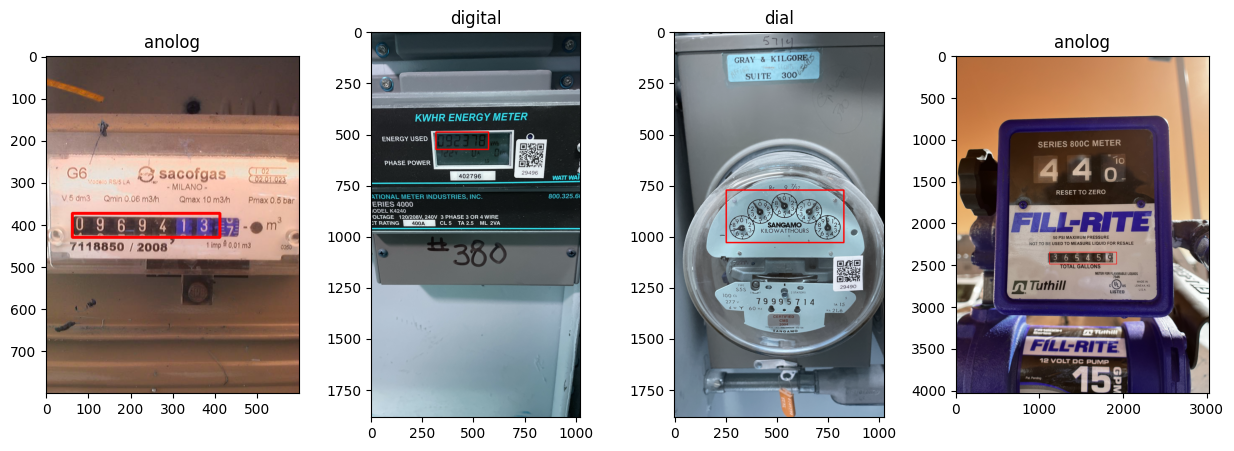

In [1038]:
imgs = []
for i, file in enumerate(glob.glob('test/*.jpg')):
    img = cv2.imread(file)
    imgs.append(img)
    x,y,w,h = xywh[i]
    cv2.rectangle(img, (x, y), (w, h), color = (255, 0, 0), thickness = 5)

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(imgs[0])
axarr[1].imshow(imgs[1])
axarr[2].imshow(imgs[2])
axarr[3].imshow(imgs[3])

#set the title
axarr[0].set_title(type[0])
axarr[1].set_title(type[1])
axarr[2].set_title(type[2])
axarr[3].set_title(type[3])

plt.show()

## image crop ##

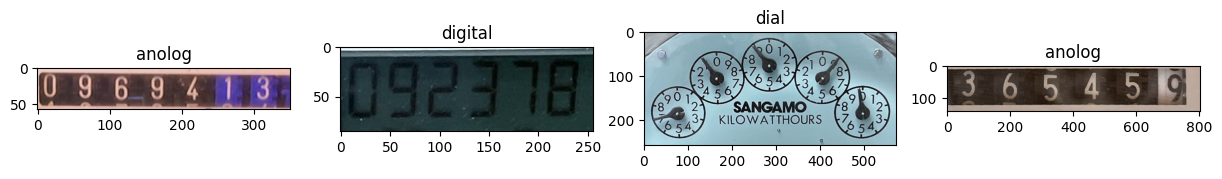

In [1039]:
import copy
xywh_copy = xywh
crop_imgs = []
crop_imgs_copy = []
for i, file in enumerate(glob.glob('test/*.jpg')):
    img = cv2.imread(file)
    x,y,w,h = xywh[i]
    crop_imgs.append(img[y:h, x:w])
    crop_imgs_copy.append(copy.deepcopy(img[y:h, x:w]))

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(crop_imgs[0])
axarr[1].imshow(crop_imgs[1])
axarr[2].imshow(crop_imgs[2])
axarr[3].imshow(crop_imgs[3])

axarr[0].set_title(type[0])
axarr[1].set_title(type[1])
axarr[2].set_title(type[2])
axarr[3].set_title(type[3])
plt.show()


# Load digits detection model #

In [1040]:
model = torch.load('digitsModel.pt')
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# convert crop image to tensor and put into model #

In [1041]:
import torchvision
import cv2
import digitsDetection as dd
def anologr(img, file_boxes):
    #img_t = transform(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
    img_t,_= dd.get_transform(train=False)(Image.fromarray(img),Image.fromarray(img))
    with torch.no_grad():
        prediction = model([img_t])
    #print(prediction[0]['scores'], prediction[0]['labels'])
    filtered_indices = sorted(
        torchvision.ops.nms(prediction[0]['boxes'], prediction[0]['scores'], iou_threshold=0.5).tolist(),
        key=lambda index: prediction[0]['boxes'][index, 0].item()
    )
    
    prediction[0] = {key: prediction[0][key][filtered_indices] for key in ('boxes', 'labels', 'scores')}

    bboxes, labels, scores= prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']
    #print(labels, scores)
    boxes = bboxes.detach().numpy()
    l = labels.detach().numpy()
    xywh = []
    for i in range(len(boxes)):
        x,y,w,h = boxes[i]
        x,y,w,h = int(x), int(y), int(w), int(h)
        xywh.append([x,y,w,h])
        cv2.rectangle(img, (x, y), (w, h), color = (255, 0, 0), thickness = 2)
        #cv2.putText(img, str(l[i]), (x, y+30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
    file_boxes.append(xywh)
    return file_boxes

In [1042]:
def plot_img(imgs, n):

    if n == 1:
        plt.imshow(imgs[0])
        plt.show()
        return
    else:
        f, axarr = plt.subplots(1,n, figsize=(15, 5))
        figsize=(8, 6)
        for i in range(n):
            axarr[i].imshow(imgs[i])

        plt.show()

## show output ##

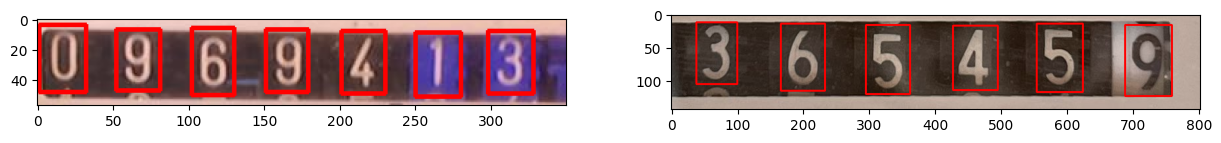

In [1043]:
file_boxes = []
imgz = []
original_imgs = []
for i, img in enumerate(crop_imgs):
    if type[i] == 'anolog':
        boxes = anologr(img, file_boxes)
        imgz.append(img)
        original_imgs.append(crop_imgs_copy[i])

plot_img(imgz, len(imgz))


# segmentation #

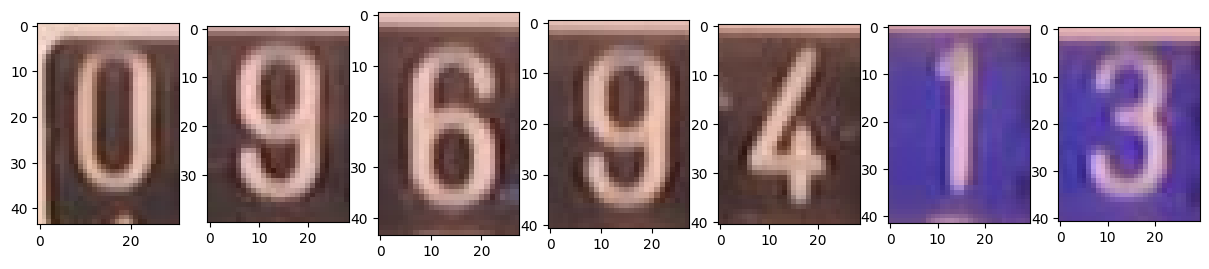

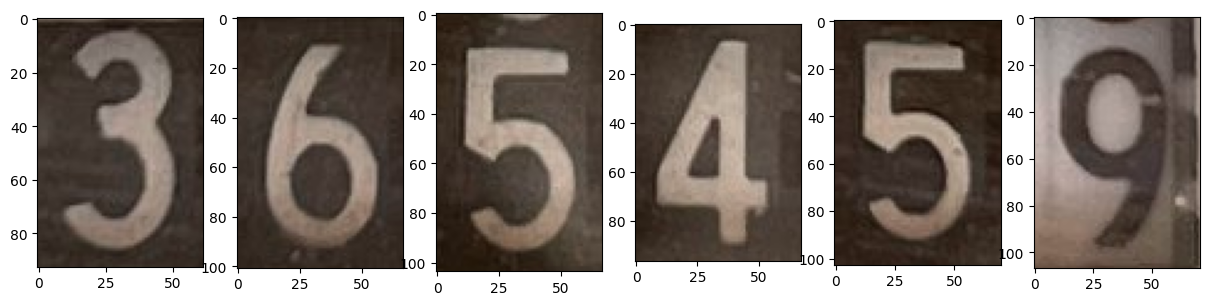

In [1044]:
crop_seg = []
for i, img in enumerate(original_imgs):
    crop_i = []
    for j, box in enumerate(file_boxes[i]):
        x,y,w,h = box
        crop_i.append(img[y:h, x:w])
    crop_seg.append(crop_i)
    plot_img(crop_i, len(crop_i))


# recognition model load #

In [1045]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.Resize((20, 32)),
    transforms.ToTensor(),
    # grayscale
    #transforms.Grayscale(num_output_channels=1)
])
class analogReadingModel(nn.Module):
    def __init__(self):
        super(analogReadingModel, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=3,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(1280, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x    # return x for visualization
model = torch.load('cnn_model/analogreadingmodel.pt')
model.eval()

analogReadingModel(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1280, out_features=10, bias=True)
)

# image to tensor and put in model #

In [1046]:
import numpy as np
import torch.nn.functional as F
def get_value(img):
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_tensor = transform(Image.fromarray(img))
    o = model(img_tensor.unsqueeze(0))
    # Convert the logits to probabilities using softmax
    probs = F.softmax(o[0], dim=1)
    # Get the predicted class and the corresponding confidence level
    pred_class = torch.argmax(probs, dim=1)
    confidence_level = torch.max(probs, dim=1).values.item()
    print('Predicted class: {}, confidence level: {}'.format(pred_class.item(), confidence_level))

    return [pred_class.item(), round(confidence_level,2)]
values = []
for i in crop_seg:
    value = []
    for img in i:
        value.append(get_value(img))
    values.append(value)
    print(values)

Predicted class: 0, confidence level: 1.0
Predicted class: 9, confidence level: 0.981428861618042
Predicted class: 6, confidence level: 0.5436921119689941
Predicted class: 9, confidence level: 0.9997255206108093
Predicted class: 4, confidence level: 0.9999794960021973
Predicted class: 1, confidence level: 0.9999997615814209
Predicted class: 3, confidence level: 0.8472606539726257
[[[0, 1.0], [9, 0.98], [6, 0.54], [9, 1.0], [4, 1.0], [1, 1.0], [3, 0.85]]]
Predicted class: 3, confidence level: 0.9926872253417969
Predicted class: 6, confidence level: 0.9803542494773865
Predicted class: 5, confidence level: 0.9999998807907104
Predicted class: 4, confidence level: 0.9959420561790466
Predicted class: 5, confidence level: 1.0
Predicted class: 0, confidence level: 0.9887505173683167
[[[0, 1.0], [9, 0.98], [6, 0.54], [9, 1.0], [4, 1.0], [1, 1.0], [3, 0.85]], [[3, 0.99], [6, 0.98], [5, 1.0], [4, 1.0], [5, 1.0], [0, 0.99]]]


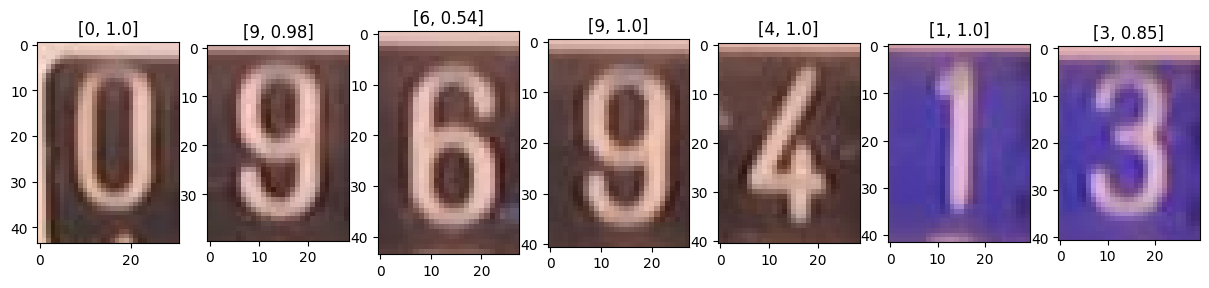

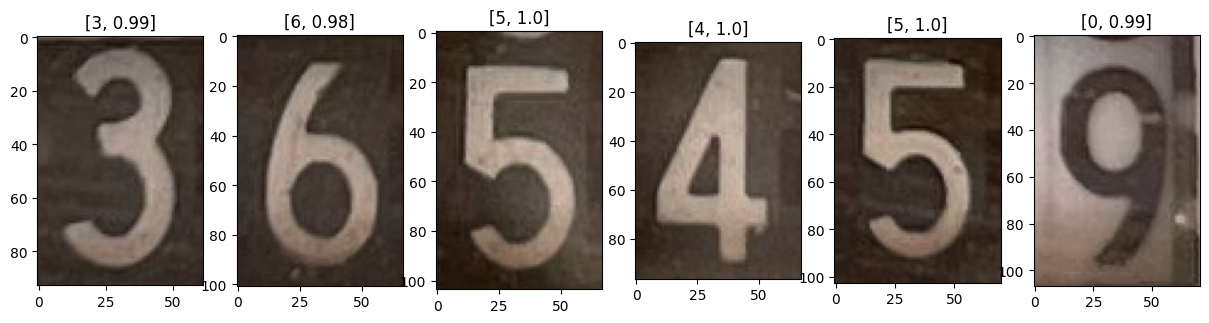

In [1047]:

import anologRecognition as anolog

for i, img in enumerate(crop_seg):
    f, axarr = plt.subplots(1,len(crop_seg[i]), figsize=(15, 5))
    figsize=(8, 6)
    for j, img in enumerate(crop_seg[i]):
        axarr[j].imshow(img)
        axarr[j].set_title(values[i][j])


# Digital #

load digits detection model

In [1048]:
model = torch.load('digitalModel.pt')
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# draw bouding boxes #

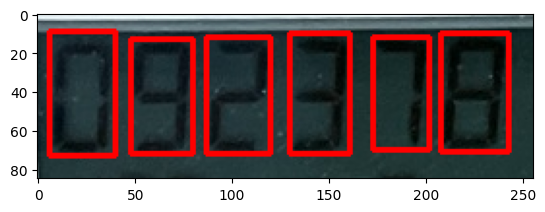

In [1049]:
import copy
file_boxes = []
imgz = []
original_imgs = []
for_plot = []
bboxes = []
for i, img in enumerate(crop_imgs):
    if type[i] == 'digital':
        for_plot.append(img.copy())
        bboxes = anologr(img, file_boxes)[0]
        imgz.append(img)
        original_imgs.append(crop_imgs_copy[i])

plot_img(imgz, 1)

# image processing #

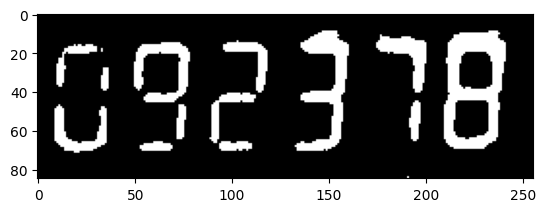

In [1050]:
import numpy as np
img = original_imgs[0]
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img = cv2.medianBlur(img, 5)
ret,img = cv2.threshold(img ,30,255,cv2.THRESH_BINARY_INV)
#invert
th1 = cv2.bitwise_not(img)
original_imgs[0] = img
plt.imshow(img, cmap='gray')
plt.show()


# Segmentation # 

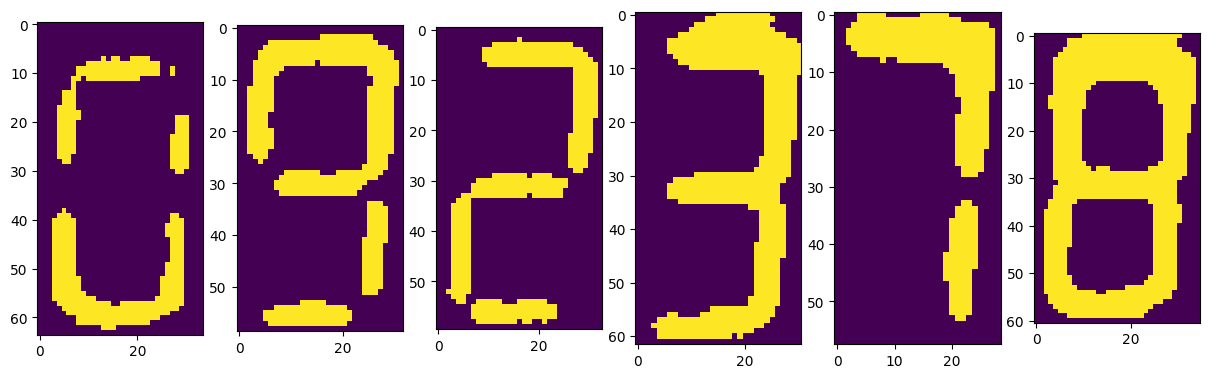

In [1051]:
crop_more = []
offset = 0
for c in bboxes:
	x, y, w, h = c
	roi = original_imgs[0][y-offset:h+offset, x-offset:w+offset]
	crop_more.append(roi)
plot_img(crop_more, len(crop_more))

# load recognition model for digtial #

In [1053]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.Resize((62, 100)),
    transforms.ToTensor(),
    #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    # grayscale
    transforms.Grayscale(num_output_channels=1)
])
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(12000, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x    # return x for visualization
model = torch.load('cnn_model/digitalreadingmodel.pt')
model.eval()

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=12000, out_features=10, bias=True)
)

# Model ouput #

In [1054]:
import numpy as np
import torch.nn.functional as F
def get_value(img):
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_tensor = transform(Image.fromarray(img))
    o = model(img_tensor.unsqueeze(0))
    # Convert the logits to probabilities using softmax
    probs = F.softmax(o[0], dim=1)
    # Get the predicted class and the corresponding confidence level
    pred_class = torch.argmax(probs, dim=1)
    confidence_level = torch.max(probs, dim=1).values.item()
    print('Predicted class: {}, confidence level: {}'.format(pred_class.item(), confidence_level))

    return [pred_class.item(), round(confidence_level,2)]
value = []
for img in crop_more:
    value.append(get_value(img))

Predicted class: 0, confidence level: 0.9583364129066467
Predicted class: 9, confidence level: 0.6018126010894775
Predicted class: 2, confidence level: 1.0
Predicted class: 3, confidence level: 0.9956633448600769
Predicted class: 7, confidence level: 0.9695532917976379
Predicted class: 2, confidence level: 0.5078673958778381


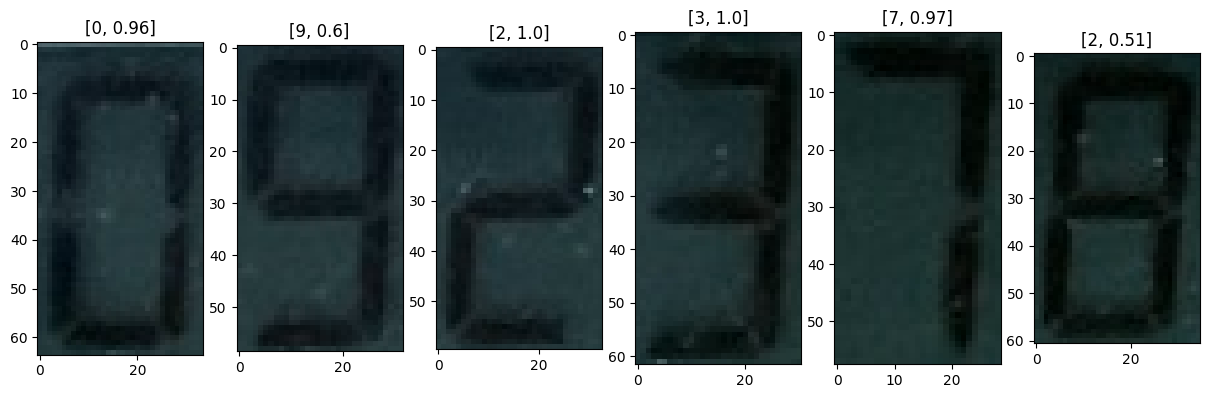

In [1055]:

final = []
offset = 0
for c in bboxes:
	x, y, w, h = c
	roi = for_plot[0][y-offset:h+offset, x-offset:w+offset]
	final.append(roi)
f, axarr = plt.subplots(1,len(bboxes), figsize=(15, 5))
figsize=(8, 6)
for i, img in enumerate(final):
	axarr[i].imshow(img)
	axarr[i].set_title(value[i])



# Dial #